# TP19 - Parcours de graphes - Wikipedia Game

!!! info Problème
Vous jouez au Wikipedia Game, le but est de partir d'une page wikipédia et en cliquant sur des liens à arriver vers une page spécifique \
_Exemple : Fontainebleau $\rightarrow$ Commune $\rightarrow$ Démographie de la France $\rightarrow$ Statistique $\rightarrow$ Informatique_ .  
!!!

!!! example Modélisation
Il s'agit d'un graphe orienté $G=(S,A)$:
- **Sommets**($S$) : Les pages.
- **Arcs** ($A$) : Les liens hypertextes. S'il y a un lien sur la page A qui mène à la page B, la flèche fait $A \rightarrow B$

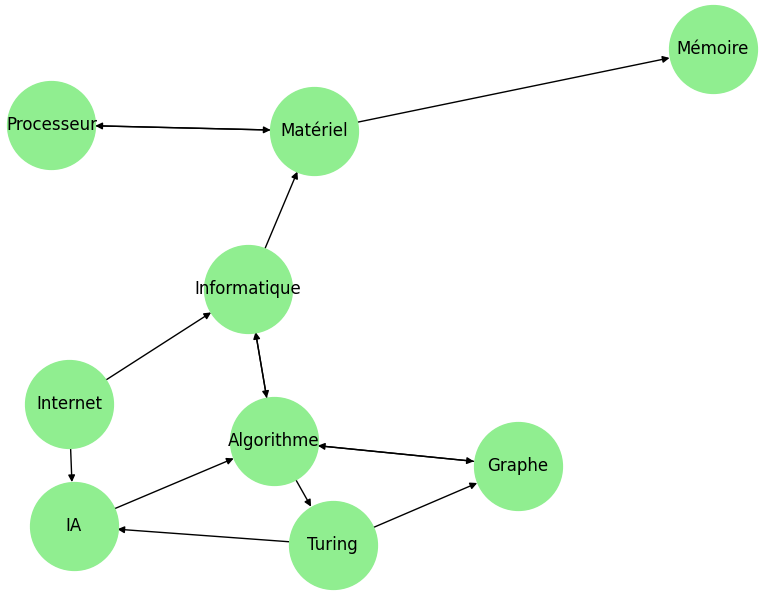
!!!

In [ ]:
# Modélisation du "Wikipedia Game"
# Clé : Article source
# Valeur : Liste des liens cliquables présents dans l'article
wikipedia_game = {
    'Informatique': ['Algorithme', 'Matériel'],
    'Algorithme': ['Informatique', 'Turing', 'Graphe'],
    'Matériel': ['Processeur', 'Mémoire'],
    'Turing': ['IA', 'Graphe'],
    'Graphe': ['Algorithme'],
    'Internet': ['IA', 'Informatique'],
    'Processeur': ['Matériel'],
    'Mémoire': [], # aucun lien sortant
    'IA': ['Algorithme']
}

!!! question Question 1
Implémenter la fonction `parcours_profondeur(graphe: dict[str: list[str]], source: str) -> list[str]` qui renvoie les sommets visité par le parcours en profondeurs depuis `source`.
!!!

<style>
    .aide-dfs-container, .aide-bfs-container {
        margin: 20px 0;
    }
    .aide-dfs-details, .aide-bfs-details {
        border: 2px dashed #9c27b0;
        border-radius: 8px;
        background-color: #f3e5f5;
        transition: all 0.3s ease;
    }
    .aide-bfs-details {
        border-color: #03a9f4;
        background-color: #e1f5fe;
    }
    .aide-dfs-summary, .aide-bfs-summary {
        padding: 10px;
        font-weight: bold;
        color: #7b1fa2;
        cursor: pointer;
        list-style: none;
        text-align: center;
    }
    .aide-bfs-summary {
        color: #0288d1;
    }
    .aide-dfs-summary:hover { background-color: #e1bee7; }
    .aide-bfs-summary:hover { background-color: #b3e5fc; }
    
    .aide-dfs-summary:before { content: "🔍 "; }
    .aide-bfs-summary:before { content: "🌊 "; }

    .aide-dfs-content, .aide-bfs-content {
        padding: 15px;
        border-top: 1px solid #ce93d8;
        color: #333;
    }
    .aide-bfs-content { border-top-color: #81d4fa; }

    .code-logic {
        font-family: 'Courier New', Courier, monospace;
        font-weight: bold;
        color: #d81b60;
    }
    .indent {
        margin-left: 20px;
        border-left: 1px solid #ccc;
        padding-left: 10px;
    }
</style>
<div class="aide-dfs-container">
<details class="aide-dfs-details">
<summary class="aide-dfs-summary">Voir pour aide : Algorithme de parcours en profondeur</summary>
<div class="aide-dfs-content">

<span class="code-logic">parcours_profondeur(graphe, source) :</span>
<div class="indent">
    • Initialiser une <span class="code-logic">pile</span> avec <span class="code-logic">source</span><br>
    • Initialiser un ensemble <span class="code-logic">visites</span> vide<br>
    • Initialiser une liste <span class="code-logic">res</span> vide<br>
    • <b>Tant que</b> la <span class="code-logic">pile</span> n'est pas vide :
    <div class="indent">
        • <b>Dépiler</b> le dernier élément : <span class="code-logic">page</span> ← pile.pop()<br>
        • <b>Si</b> <span class="code-logic">page</span> n'est pas dans <span class="code-logic">visites</span> :<br>
        <div class="indent">
            • L'ajouter à <span class="code-logic">visites</span><br>
            • L'ajouter à <span class="code-logic">res</span><br>
            • <b>Pour chaque</b> <span class="code-logic">successeur</span> de <span class="code-logic">page</span> :<br>
            <div class="indent">
                • <b>Si</b> <span class="code-logic">successeur</span> n'est pas visité : <b>Empiler</b> <span class="code-logic">successeur</span>
            </div>
        </div>
    </div>
    • <b>Retourner</b> <span class="code-logic">res</span>
</div>

</div>
</details>
</div>


In [ ]:
print(parcours_profondeur(wikipedia_game, 'Processeur')) # ['Processeur', 'Matériel', 'Mémoire']

In [ ]:
print(parcours_profondeur(wikipedia_game, 'Informatique'))

!!! question Question 2 
Écrire une fonction `est_accessible(graphe: dict[str: list[str]], source:str, destination: str) -> bool` 
qui dit si on peut accéder à la `destination` depuis la source.
!!!

In [ ]:
print(est_accessible(wikipedia_game, 'Processeur', 'Informatique')) #False

In [ ]:
print(est_accessible(wikipedia_game, 'Informatique', 'Graphe')) #True

!!! question Question 3
On cherche à déterminer si 2 pages sont dans la même composante fortement connexe, donc si $u$ est accessible depuis $v$ et inversement. \
Écrire une fonction `sont_fortement_connexe(graphe: dict[str:list[str]], u:str , v: str) -> bool`
!!!

In [ ]:
print(sont_fortement_connexe(wikipedia_game, 'Internet', 'Graphe')) #False

In [ ]:
print(sont_fortement_connexe(wikipedia_game, 'IA', 'Graphe')) #True

## Exercice 2 : Autour du parcours en largeur

Contrairement au DFS, le parcours en largeur s'étend comme une onde à la surface de l'eau. Il explore d'abord tous les voisins immédiats (distance 1), puis les voisins des voisins (distance 2), etc.

Pour implémenter le parcours en largeur on va utiliser la structure de file (FIFO). Pour commencer on va créer une file grâce à une liste dans laquelle on va retiré le premier élément en faisant `file.pop(0)`

!!! question Question 1
Implémenter la fonction `parcours_largeur(graphe: dict[str: list[str]], source: str) -> list[str]` qui renvoie les sommets visité par le parcours en profondeurs depuis `source`.
!!!
<style>
    .aide-bfs-container {
        margin: 20px 0;
    }
    .aide-bfs-details {
        border: 2px dashed #03a9f4;
        border-radius: 8px;
        background-color: #e1f5fe;
        transition: all 0.3s ease;
    }
    .aide-bfs-summary {
        padding: 10px;
        font-weight: bold;
        color: #0288d1;
        cursor: pointer;
        list-style: none;
        text-align: center;
    }
    .aide-bfs-summary:hover { background-color: #b3e5fc; }
    .aide-bfs-summary:before { content: "🌊 "; }

    .aide-bfs-content {
        padding: 15px;
        border-top: 1px solid #81d4fa;
        color: #333;
    }

    .code-logic {
        font-family: 'Courier New', Courier, monospace;
        font-weight: bold;
        color: #d81b60;
    }
    .indent {
        margin-left: 20px;
        border-left: 1px solid #ccc;
        padding-left: 10px;
    }
</style>

<div class="aide-bfs-container">
    <details class="aide-bfs-details">
        <summary class="aide-bfs-summary">Voir pour aide : Algorithme de parcours en largeur (BFS)</summary>
        <div class="aide-bfs-content">
            <span class="code-logic">parcours_largeur(graphe, source) :</span>
            <div class="indent">
                • Initialiser une <span class="code-logic">file</span> contenant <span class="code-logic">source</span><br>
                • Initialiser un ensemble <span class="code-logic">visites</span> contenant <span class="code-logic">source</span><br>
                • Initialiser une liste <span class="code-logic">res</span> vide<br>
                • <b>Tant que</b> la <span class="code-logic">file</span> n'est pas vide :
                <div class="indent">
                    • <b>Défiler</b> le premier élément : <span class="code-logic">sommet</span><br>
                    • <b>Ajouter</b> <span class="code-logic">sommet</span> dans <span class="code-logic">res</span><br>
                    • <b>Pour chaque</b> <span class="code-logic">voisin</span> de <span class="code-logic">sommet</span> :<br>
                    <div class="indent">
                        • <b>Si</b> <span class="code-logic">voisin</span> n'est pas dans <span class="code-logic">visites</span> :<br>
                        <div class="indent">
                            • <b>Ajouter</b> <span class="code-logic">voisin</span> dans <span class="code-logic">visites</span><br>
                            • <b>Enfiler</b> <span class="code-logic">voisin</span> dans <span class="code-logic">file</span><br>
                        </div>
                    </div>
                </div>
                • <b>Retourner</b> <span class="code-logic">res</span>
            </div>
        </div>
    </details>
</div>

In [ ]:
print(parcours_largeur(wikipedia_game, 'Informatique'))

!!! info `deque`
Pour améliorer les performances de notre algorithme on va utiliser `deque` du module `collections`\
Pour créer une file vide on fait : `file = deque()`\
Pour créer une file avec des données on fait : `file = deque([sommet_depart])`\
Pour défiler on fait : `file.popleft()`\
Pour enfiler on fait : `file.append(x)`\
Pour regarder si la file est vide on utilise `len(file)`
!!!

!!! question Question 2 
Importer la fonction deque du module `collections` puis modifier votre fonction `parcours_largeur(graphe, source)` pour utiliser cette file.
!!!

In [ ]:
print(parcours_largeur(wikipedia_game, 'Informatique'))

!!! question Question 3
On cherche à savoir vers quelles pages on peut aller en passant par `k` pages ou moins. Pour ça écrire une fonction `accessible_en_k(graphe, source, k)` qui adapte votre parcours en largeur en stockant maintenant dans votre file des tuple `(sommet, dist)`. Puis arrêter votre algorithme dès que vous avez une distance suppérieur à `k`.
!!!

In [ ]:
print(accessible_en_k(wikipedia_game, 'Informatique', 1))

In [ ]:
print(accessible_en_k(wikipedia_game, 'Informatique', 2))

In [ ]:
print(accessible_en_k(wikipedia_game, 'Informatique', 3))

!!! question Question 4
On cherche à savoir la taille du chemin le plus court entre 2 pages (une source et une destination). Écrire une fonction `taille_plus_court_chemin(graphe, source, destination) -> int`.
!!!

In [ ]:
print(taille_plus_court_chemin(wikipedia_game, 'Informatique', 'IA'))

On cherche maintenant à récupérer le plus court chemin entre 2 pages. C'est plus compliqué. Dans un premier temps on va reconstruire un chemin depuis un dictionnaire.
!!! question Question 5
Écrire une focntion `reconstruire_chemin(dico: dict, destination: str) -> list[str]` qui depuis un dictionnaire _(que l'on construira après)_ renvoie le chemin le plus cours depuis une destination jusqu'à la source.

Le dictionnaire ressemble à celà : 
```python
dico = {'Informatique': None, 'Algorithme': 'Informatique', 'Matériel': 'Informatique', 'Turing': 'Algorithme', 'Graphe': 'Algorithme', 'Processeur': 'Matériel', 'Mémoire': 'Matériel', 'IA': 'Turing'}

```
On cherche à remonter de la destination jusqu'à la source, la source à comme valeur `None`, pour les autres sommet la valeur associé est un sommet prédécesseur à une distance de 1 de moins. 

Par exemple sur ce dico si on a la destination `IA` on va voir qu'on est arrivé en `IA` depuis `Turing` et en `Turing` depuis `Algorithme`...
!!!

In [ ]:
dico = {'Informatique': None, 'Algorithme': 'Informatique', 'Matériel': 'Informatique', 'Turing': 'Algorithme', 'Graphe': 'Algorithme', 'Processeur': 'Matériel', 'Mémoire': 'Matériel', 'IA': 'Turing'}
print(reconstruire_chemin(dico, "IA")) # ['Informatique', 'Algorithme', 'Turing', 'IA']

!!! question Question 6
Écrire la fonction `plus_court_chemin(graphe, source, destination) -> list[str]` qui créer le dictionnaire puis renvoie le chemin le plus court de la source à la destination. Pour faire celà, modifier votre ensemble `visites` en dictionnaire, où les clés seront les sommets visités et les valeurs les sommets qui ont mené à ce sommet.
!!!

In [ ]:
print(plus_court_chemin(wikipedia_game, 'Informatique', 'IA'))